# Movie Review Sentiment Classification


## Imports

In [19]:
import os
import pickle
import nltk
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from wordcloud import STOPWORDS
import string
from nltk.stem import WordNetLemmatizer
import contractions
from nltk.corpus import wordnet
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix


## Load Reviews Function
Load positive and negative reviews into a DataFrame.


In [20]:
def load_reviews(positive_folder, negative_folder):
    reviews = []
    labels = []

    for filename in os.listdir(positive_folder):
        file_path = os.path.join(positive_folder, filename)
        with open(file_path, 'r') as file:
            review_text = file.read()
            reviews.append(review_text)
            labels.append('positive')

    for filename in os.listdir(negative_folder):
        file_path = os.path.join(negative_folder, filename)
        with open(file_path, 'r') as file:
            review_text = file.read()
            reviews.append(review_text)
            labels.append('negative')

    df = pd.DataFrame({'review_text': reviews, 'sentiment': labels})
    return df


## Text Preprocessing and Lemmatization
Functions to clean and preprocess review text.


In [21]:
lemmatizer = WordNetLemmatizer()

def lemmatization_text(sentence):
    def pos_tagger(nltk_tag):
        if nltk_tag.startswith('J'):
            return wordnet.ADJ
        elif nltk_tag.startswith('V'):
            return wordnet.VERB
        elif nltk_tag.startswith('N'):
            return wordnet.NOUN
        elif nltk_tag.startswith('R'):
            return wordnet.ADV
        else:
            return None

    pos_tagged = nltk.pos_tag(nltk.word_tokenize(sentence))
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), pos_tagged))

    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            lemmatized_sentence.append(word)
        else:
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))

    return " ".join(lemmatized_sentence)


### Preprocess function

In [22]:
def preprocess_text(text):
    stop_words = set(STOPWORDS.intersection(stopwords.words('english'))) - {
        "not", "very", "wow", "oh", "yuck", "yay", "alas", "oops", "hey", "ah",
        "ouch", "phew", "damn", "hell", "ugh", "jeez", "gosh", "wowza", "whoa",
        "yikes", "meh", "huh", "yay!", "ugh!", "oh no", "nothing"
    }

    text = contractions.fix(text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', ''.join(set(string.punctuation) - {'!'})))

    # with lemmatization
    # tokens = lemmatization_text(text)
    # tokens = nltk.word_tokenize(tokens)

    # without lemmatization
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)


## Load and Preprocess Dataset
Load `movie_reviews.csv` or use `pos`/`neg` folders and apply TF-IDF vectorization.


In [23]:
# load CSV directly (or use folders)
reviews_df = pd.read_csv("movie_reviews.csv")
# At first we used: reviews_df = load_reviews("pos", "neg")

# preprocess reviews
reviews_df['review_text'] = reviews_df['review_text'].apply(preprocess_text)
reviews_df['sentiment'] = reviews_df['sentiment'].map({'positive': 1, 'negative': 0})

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=2000)
X = tfidf_vectorizer.fit_transform(reviews_df['review_text'])
y = reviews_df['sentiment']


## Training and Evaluating Models
Train Logistic Regression, SVM, Naive Bayes, Random Forest, and KNN. Evaluate with accuracy and confusion matrix.


In [24]:
model_names = []
train_accuracies = []
test_accuracies = []
confusion_matricies = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def evaluate_classifier(classifier, name, X_train, y_train, X_test, y_test):
    classifier.fit(X_train, y_train)
    y_pred_train = classifier.predict(X_train)
    y_pred = classifier.predict(X_test)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
    model_names.append(name)
    train_accuracies.append(100 * accuracy_score(y_train, y_pred_train))
    test_accuracies.append(100 * accuracy_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    confusion_matricies.append(cm)

# Evaluate models
evaluate_classifier(LogisticRegression(max_iter=1000), 'Logistic Regression', X_train, y_train, X_test, y_test)
evaluate_classifier(SVC(kernel='linear', C=1.6), 'SVM', X_train, y_train, X_test, y_test)
evaluate_classifier(MultinomialNB(), 'Naive Bayes', X_train, y_train, X_test, y_test)
evaluate_classifier(RandomForestClassifier(n_estimators=100, random_state=42), 'Random Forest', X_train, y_train, X_test, y_test)
evaluate_classifier(KNeighborsClassifier(n_neighbors=300), 'KNN', X_train, y_train, X_test, y_test)



Logistic Regression Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      0.82      0.84       200
    Positive       0.83      0.87      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400


SVM Classification Report:

              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87       200
    Positive       0.86      0.89      0.87       200

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400


Naive Bayes Classification Report:

              precision    recall  f1-score   support

    Negative       0.81      0.84      0.83       200
    Positive       0.83      0.81      0.82       200

    accuracy                           0.82       400
   macro avg     

## Accuracy Summary and Confusion Matrices
Visualize model performance and confusion matrices.


Logistic Regression Performance Summary:
Train Accuracy: 94.62%
Test Accuracy: 84.75%

SVM Performance Summary:
Train Accuracy: 97.62%
Test Accuracy: 86.75%

Naive Bayes Performance Summary:
Train Accuracy: 89.25%
Test Accuracy: 82.25%

Random Forest Performance Summary:
Train Accuracy: 100.00%
Test Accuracy: 80.75%

KNN Performance Summary:
Train Accuracy: 77.38%
Test Accuracy: 79.25%



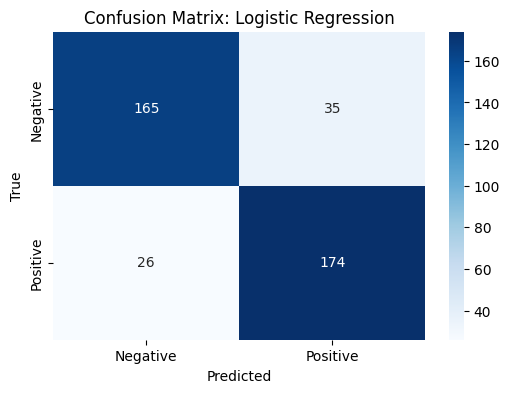

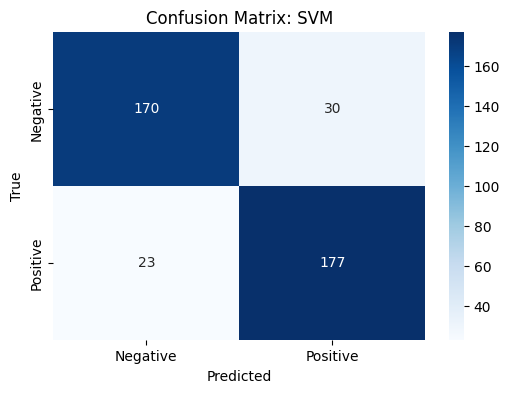

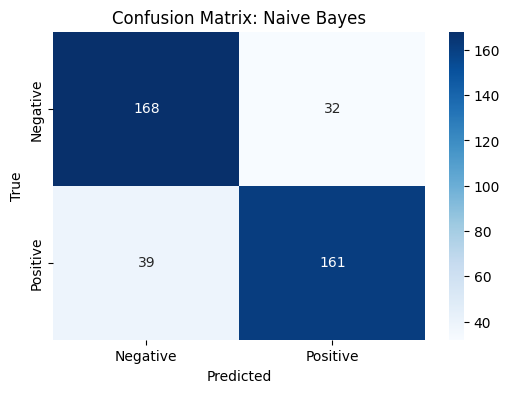

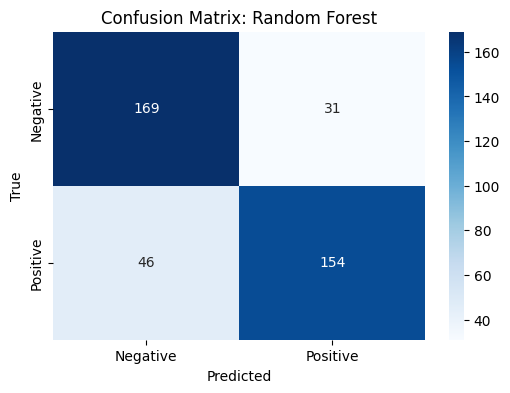

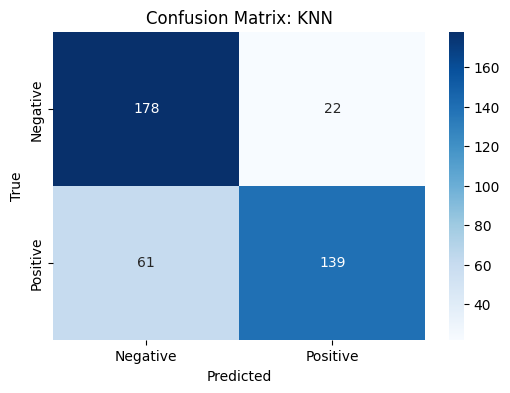

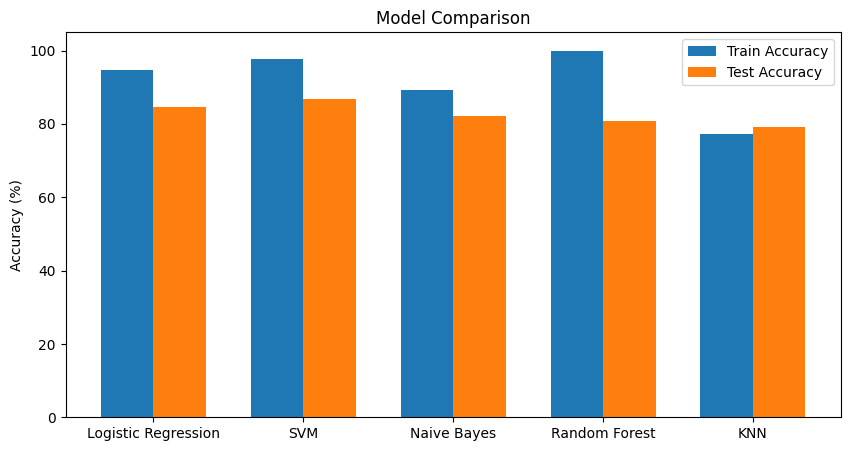

In [25]:
# print accuracies
for i, name in enumerate(model_names):
    print(f"{name} Performance Summary:")
    print(f"Train Accuracy: {train_accuracies[i]:.2f}%")
    print(f"Test Accuracy: {test_accuracies[i]:.2f}%\n")

# confusion matrices
for i, cm in enumerate(confusion_matricies):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix: {model_names[i]}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# accuracy bar plot
plt.figure(figsize=(10, 5))
x = range(len(model_names))
plt.bar(x, train_accuracies, width=0.35, label='Train Accuracy')
plt.bar([i + 0.35 for i in x], test_accuracies, width=0.35, label='Test Accuracy')
plt.xticks([i + 0.175 for i in x], model_names)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.legend()
plt.show()


## Predict Sample Text with Full Models
Train on full data and predict a new review.


In [26]:
# training
CompleteLogistic = LogisticRegression(max_iter=1000).fit(X, y)
CompleteSVM = SVC(kernel='linear', C=1.6).fit(X, y)
CompleteNB = MultinomialNB().fit(X, y)
CompleteRF = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)
CompleteKNN = KNeighborsClassifier(n_neighbors=300).fit(X, y)

# sample prediction
input_text = "it was a great movie"
input_text = preprocess_text(input_text)
features = tfidf_vectorizer.transform([input_text])

print(f"Logistic: {'Positive' if CompleteLogistic.predict(features)[0] else 'Negative'}")
print(f"SVM: {'Positive' if CompleteSVM.predict(features)[0] else 'Negative'}")
print(f"Naive Bayes: {'Positive' if CompleteNB.predict(features)[0] else 'Negative'}")
print(f"Random Forest: {'Positive' if CompleteRF.predict(features)[0] else 'Negative'}")
print(f"KNN: {'Positive' if CompleteKNN.predict(features)[0] else 'Negative'}")


Logistic: Positive
SVM: Positive
Naive Bayes: Positive
Random Forest: Positive
KNN: Positive


## Save Models and Vectorizer
Store trained models and vectorizer with pickle for deployment.


In [27]:
# pickle.dump(CompleteLogistic, open('models/Logistic_Regression.pkl', 'wb'))
# pickle.dump(CompleteSVM, open('models/SVM.pkl', 'wb')) 
# pickle.dump(CompleteNB, open('models/Naive_Bayes.pkl', 'wb'))
# pickle.dump(CompleteRF, open('models/Random_Forest.pkl', 'wb'))
# pickle.dump(CompleteKNN, open('models/KNN.pkl', 'wb'))
# pickle.dump(tfidf_vectorizer, open('models/tfidf_vectorizer.pkl', 'wb'))